# E-commerce Conversion Analytics and Purchase Propensity ML

## tl;dr

- 310,014 sessions produced 4,247 purchases and a 1.37% conversion rate.
- The largest funnel loss occurs from Visit to Product View.
- The highest-scored 10% of future sessions captures 20.1% of purchases at 2.01x lift.
- This notebook reads the external `data/session_level_ecommerce.csv.gz` file and shows every analytical output and chart.

## Context & Methods

The notebook combines funnel analytics, a leakage-safe feature contract, chronological model validation, lift analysis, calibration, and experiment design. All narrative, code, tables, and charts are kept together for portfolio review.

### 1. Setup

In [1]:
from pathlib import Path
import hashlib
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2E74B5", "#B4872B", "#64748B", "#0F766E"]
print(f"pandas {pd.__version__} | NumPy {np.__version__}")

pandas 2.3.3 | NumPy 2.4.1


### 2. Load the external session-level CSV

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "session_level_ecommerce.csv.gz").exists():
    PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "session_level_ecommerce.csv.gz"
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Expected data/session_level_ecommerce.csv.gz. Run the notebook from the repository root "
        "or keep the original repository folder structure."
    )
df = pd.read_csv(DATA_PATH, parse_dates=["session_date"])
print(f"Loaded {len(df):,} sessions and {len(df.columns)} columns from {DATA_PATH}")
display(df.head())

Loaded 310,014 sessions and 30 columns from data/session_level_ecommerce.csv.gz


session_id,user_pseudo_id,ga_session_id,session_date,day_of_week,is_weekend,traffic_source,traffic_medium,device_category,operating_system,country,total_events,distinct_event_types,page_views,product_views,add_to_cart_events,checkout_events,shipping_events,payment_events,purchase_events,viewed_product,added_to_cart,began_checkout,added_shipping_info,added_payment_info,converted,transaction_count,revenue,session_duration_seconds,engagement_time_seconds
7802771.1242374269-5349183729,7.802771e+06,5349183729,2020-11-16,2,0,(direct),(none),mobile,Android,Turkey,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,928.531
48923044.1784847148-2085685405,4.892304e+07,2085685405,2020-11-16,2,0,(direct),(none),desktop,Web,United States,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,5.710
2342957.9635959151-4434005275,2.342958e+06,4434005275,2020-11-16,2,0,shop.googlemerchandisestore.com,referral,mobile,Web,India,2,2,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,0.000
44249101.7248838631-8478097236,4.424910e+07,8478097236,2020-11-16,2,0,<Other>,<Other>,mobile,Web,(not set),2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.000
83459313.5629300570-8765897980,8.345931e+07,8765897980,2020-11-16,2,0,(data deleted),(data deleted),mobile,Web,United Kingdom,2,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.000


## Data

### 3. Validate input quality and the session key

In [3]:
required = [
    "session_id", "session_date", "day_of_week", "is_weekend", "traffic_source",
    "traffic_medium", "device_category", "operating_system", "country", "converted",
]
missing_columns = sorted(set(required) - set(df.columns))
quality = pd.DataFrame({
    "check": ["Required columns missing", "Missing values", "Duplicate session IDs", "Start date", "End date"],
    "result": [
        str(missing_columns), int(df[required].isna().sum().sum()),
        int(df["session_id"].duplicated().sum()), df["session_date"].min().date(),
        df["session_date"].max().date(),
    ],
})
assert not missing_columns
assert df["session_id"].is_unique
display(quality)
print("Data-quality checks passed.")

check,result
Required columns missing,[]
Missing values,0
Duplicate session IDs,0
Start date,2020-11-16
End date,2021-01-31


Data-quality checks passed.


### 4. Review business KPIs

In [4]:
kpis = pd.DataFrame({
    "KPI": ["Sessions", "Purchases", "Conversion rate", "Recorded revenue", "Revenue per session"],
    "Value": [
        f"{len(df):,}", f"{int(df['converted'].sum()):,}", f"{df['converted'].mean():.2%}",
        f"${df['revenue'].sum():,.0f}", f"${df['revenue'].sum()/len(df):.2f}",
    ],
})
display(kpis)


KPI,Value
Sessions,"310,014"
Purchases,"4,247"
Conversion rate,1.37%
Recorded revenue,"$315,948"
Revenue per session,$1.02


## Results

### 5. Build and visualize the conversion funnel

stage,sessions,stage_conversion,drop_off
Visit,310014,1.0000,NaN
Product View,65393,0.2109,244621.0
Add to Cart,15187,0.2322,50206.0
Checkout,9086,0.5983,6101.0
Payment,5875,0.6466,3211.0
Purchase,4247,0.7229,1628.0


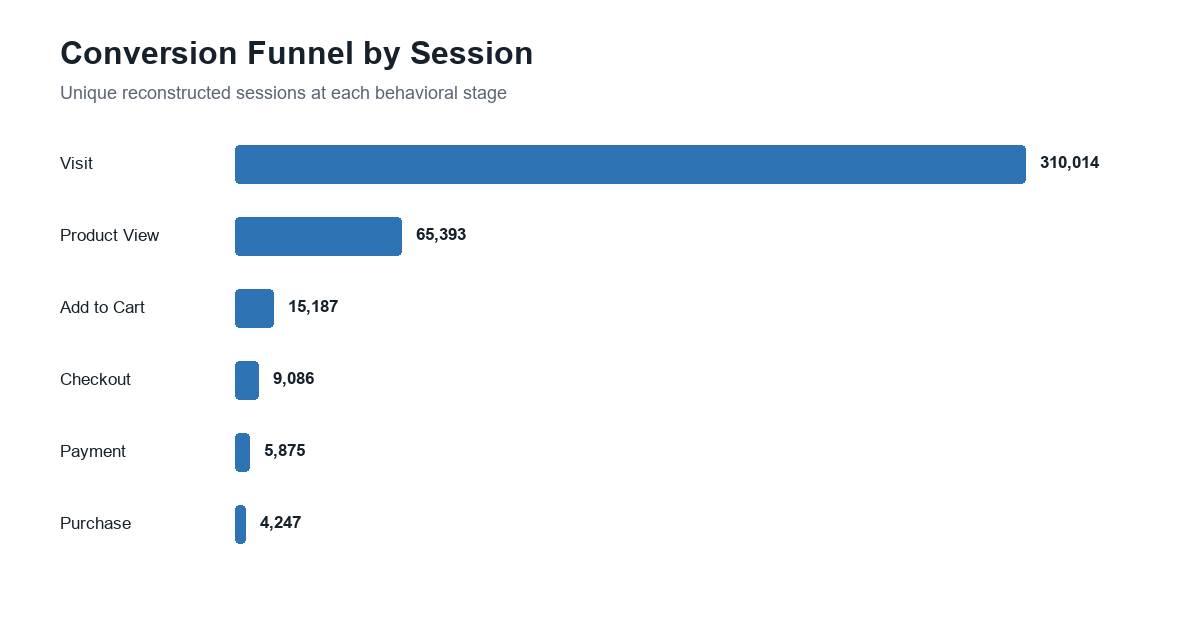

In [5]:
funnel = pd.DataFrame({
    "stage": ["Visit", "Product View", "Add to Cart", "Checkout", "Payment", "Purchase"],
    "sessions": [
        len(df), int(df["viewed_product"].sum()), int(df["added_to_cart"].sum()),
        int(df["began_checkout"].sum()), int(df["added_payment_info"].sum()),
        int(df["converted"].sum()),
    ],
})
funnel["stage_conversion"] = funnel["sessions"] / funnel["sessions"].shift(1)
funnel.loc[0, "stage_conversion"] = 1.0
funnel["drop_off"] = funnel["sessions"].shift(1) - funnel["sessions"]
display(funnel)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.barh(funnel["stage"], funnel["sessions"], color=COLORS[0])
ax.invert_yaxis()
ax.set_title("Conversion Funnel by Session", loc="left", fontsize=16, weight="bold", pad=16)
ax.set_xlabel("Sessions")
ax.margins(x=0.22)
for bar, value in zip(bars, funnel["sessions"]):
    ax.text(value + 4000, bar.get_y() + bar.get_height()/2, f"{value:,}", va="center")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()

### 6. Create a chronological train/test split

In [6]:
TEST_START = pd.Timestamp("2021-01-11")
train = df[df["session_date"] < TEST_START].copy()
test = df[df["session_date"] >= TEST_START].copy()
y_train = train["converted"].astype(int).to_numpy()
y_test = test["converted"].astype(int).to_numpy()
split_summary = pd.DataFrame({
    "sample": ["Train", "Test"],
    "start": [train["session_date"].min().date(), test["session_date"].min().date()],
    "end": [train["session_date"].max().date(), test["session_date"].max().date()],
    "sessions": [len(train), len(test)],
    "purchases": [int(y_train.sum()), int(y_test.sum())],
    "conversion_rate": [y_train.mean(), y_test.mean()],
})
display(split_summary)

sample,start,end,sessions,purchases,conversion_rate
Train,2020-11-16,2021-01-10,228487,3335,0.014596
Test,2021-01-11,2021-01-31,81527,912,0.011187


### 7. Define deterministic leakage-safe models and metrics


In [7]:
def decile_table(y, p):
    order = np.argsort(-p, kind="mergesort")
    decile = np.empty(len(y), dtype=int)
    decile[order] = np.minimum(
        10, np.floor(np.arange(len(y)) * 10 / len(y)).astype(int) + 1
    )
    scored = pd.DataFrame(
        {"converted": y, "score": p, "score_decile": decile}
    )
    base_rate = scored["converted"].mean()
    result = scored.groupby("score_decile").agg(
        sessions=("converted", "size"),
        purchases=("converted", "sum"),
        avg_score=("score", "mean"),
        observed_rate=("converted", "mean"),
    ).reset_index()
    result["lift_vs_average"] = result["observed_rate"] / base_rate
    return result


def calibration_table(y, p):
    order = np.argsort(p, kind="mergesort")
    band = np.empty(len(y), dtype=int)
    band[order] = np.minimum(
        10, np.floor(np.arange(len(y)) * 10 / len(y)).astype(int) + 1
    )
    scored = pd.DataFrame({"converted": y, "score": p, "risk_band": band})
    return scored.groupby("risk_band").agg(
        sessions=("converted", "size"),
        predicted_rate=("score", "mean"),
        observed_rate=("converted", "mean"),
    ).reset_index()


def stable_bucket(value, column, buckets):
    raw = f"{column}={value}".encode("utf-8", errors="replace")
    return int.from_bytes(hashlib.blake2b(raw, digest_size=8).digest(), "little") % buckets

def hash_matrix(frame, buckets):
    matrices = []
    for column in SAFE_FEATURES:
        values = frame[column].fillna("<MISSING>").astype(str)
        mapping = {value: stable_bucket(value, column, buckets) for value in values.unique()}
        matrices.append(values.map(mapping).to_numpy(dtype=np.int32))
    return np.column_stack(matrices)

def sigmoid(z):
    z = np.clip(z, -35.0, 35.0)
    return 1.0 / (1.0 + np.exp(-z))

def fit_hashed_logistic(x_idx, y, buckets=2048, epochs=30, batch_size=8192, learning_rate=0.08, l2=1e-5):
    rng = np.random.default_rng(20260729)
    w = np.zeros(buckets, dtype=np.float64)
    b = float(np.log(y.mean() / (1.0 - y.mean())))
    mw, vw = np.zeros_like(w), np.zeros_like(w)
    mb = vb = 0.0
    beta1, beta2, eps, step = 0.9, 0.999, 1e-8, 0
    history = []
    for _ in range(epochs):
        order = rng.permutation(len(y))
        for start in range(0, len(y), batch_size):
            ids = order[start:start + batch_size]
            xb, yb = x_idx[ids], y[ids]
            p = sigmoid(b + w[xb].sum(axis=1))
            err = p - yb
            grad = np.zeros_like(w)
            for j in range(xb.shape[1]):
                np.add.at(grad, xb[:, j], err)
            grad = grad / len(ids) + l2 * w
            grad_b = float(err.mean())
            step += 1
            mw, vw = beta1 * mw + (1-beta1) * grad, beta2 * vw + (1-beta2) * grad * grad
            mb, vb = beta1 * mb + (1-beta1) * grad_b, beta2 * vb + (1-beta2) * grad_b * grad_b
            w -= learning_rate * (mw / (1-beta1**step)) / (np.sqrt(vw / (1-beta2**step)) + eps)
            b -= learning_rate * (mb / (1-beta1**step)) / (np.sqrt(vb / (1-beta2**step)) + eps)
        p_all = sigmoid(b + w[x_idx].sum(axis=1))
        history.append(float(-np.mean(y*np.log(np.clip(p_all, 1e-12, 1)) + (1-y)*np.log(np.clip(1-p_all, 1e-12, 1)))))
    return w, b, history
def fit_categorical_naive_bayes(frame, y, alpha=10.0):
    model = {"prior": float((y.sum()+alpha)/(len(y)+2*alpha)), "columns": {}}
    for column in SAFE_FEATURES:
        values = frame[column].fillna("<MISSING>").astype(str)
        table = pd.crosstab(values, y)
        for cls in [0, 1]:
            if cls not in table.columns:
                table[cls] = 0
        n_values, probs, defaults = len(table)+1, {}, {}
        for cls in [0, 1]:
            denom = float((y == cls).sum() + alpha*n_values)
            probs[str(cls)] = ((table[cls]+alpha)/denom).to_dict()
            defaults[str(cls)] = alpha/denom
        model["columns"][column] = {"probs": probs, "defaults": defaults}
    return model

def predict_categorical_naive_bayes(model, frame):
    prior = model["prior"]
    log0, log1 = np.full(len(frame), np.log(1-prior)), np.full(len(frame), np.log(prior))
    for column in SAFE_FEATURES:
        values, spec = frame[column].fillna("<MISSING>").astype(str), model["columns"][column]
        log0 += np.log(values.map(spec["probs"]["0"]).fillna(spec["defaults"]["0"]).to_numpy())
        log1 += np.log(values.map(spec["probs"]["1"]).fillna(spec["defaults"]["1"]).to_numpy())
    return sigmoid(log1-log0)

def average_precision(y, p):
    ys = y[np.argsort(-p, kind="mergesort")]
    return float(((np.cumsum(ys)/np.arange(1, len(ys)+1))*ys).sum()/ys.sum())

def roc_auc(y, p):
    order, ranks, sorted_p = np.argsort(p, kind="mergesort"), np.empty(len(p)), np.sort(p, kind="mergesort")
    i = 0
    while i < len(p):
        j = i + 1
        while j < len(p) and sorted_p[j] == sorted_p[i]:
            j += 1
        ranks[order[i:j]] = (i + 1 + j) / 2
        i = j
    n1, n0 = y.sum(), len(y)-y.sum()
    return float((ranks[y == 1].sum()-n1*(n1+1)/2)/(n1*n0))

def evaluate(y, p, capacity=0.10):
    clipped = np.clip(p, 1e-12, 1-1e-12)
    n_top, base = int(np.ceil(len(y)*capacity)), float(y.mean())
    top = np.argsort(-p)[:n_top]
    return {
        "PR-AUC": average_precision(y, p),
        "ROC-AUC": roc_auc(y, p),
        "Log loss": float(-np.mean(y*np.log(clipped)+(1-y)*np.log(1-clipped))),
        "Brier score": float(np.mean((p-y)**2)),
        "Top-10% recall": float(y[top].sum()/y.sum()),
        "Top-10% lift": float(y[top].mean()/base),
    }
print("Model functions defined.")


Model functions defined.


### 8. Train logistic regression and Naive Bayes

In [8]:
SAFE_FEATURES = [
    "day_of_week", "is_weekend", "traffic_source", "traffic_medium",
    "device_category", "operating_system", "country",
]
HASH_BUCKETS = 2048
x_train, x_test = hash_matrix(train, HASH_BUCKETS), hash_matrix(test, HASH_BUCKETS)
weights, intercept, training_loss = fit_hashed_logistic(x_train, y_train, HASH_BUCKETS)
p_logistic = sigmoid(intercept + weights[x_test].sum(axis=1))
nb_model = fit_categorical_naive_bayes(train, y_train)
p_nb = predict_categorical_naive_bayes(nb_model, test)
probabilities = {"Hashed logistic regression": p_logistic, "Categorical Naive Bayes": p_nb}
results = pd.DataFrame({name: evaluate(y_test, p) for name, p in probabilities.items()}).T
display(results.round(4))
print(f"Selected by PR-AUC: {results['PR-AUC'].idxmax()}")

model,pr_auc,roc_auc,log_loss,brier_score,recall_at_top_10pct,conversion_rate_top_10pct,lift_top_10pct
hashed_logistic_regression,0.0171,0.5868,0.0609,0.0110,0.2007,0.0224,2.0065
categorical_naive_bayes,0.0168,0.5947,0.0631,0.0114,0.2029,0.0227,2.0284


Selected by PR-AUC: Hashed logistic regression


### 9. Compare model discrimination and operational lift

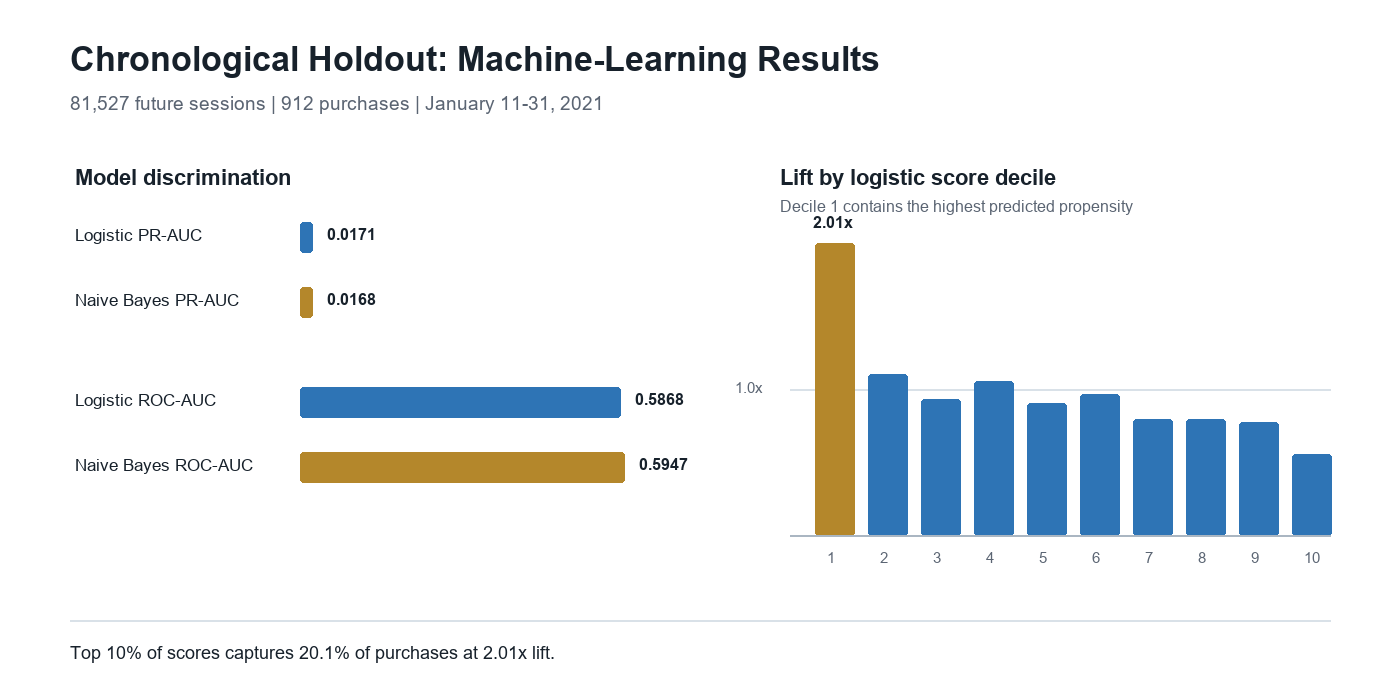

In [9]:
lift = decile_table(y_test, p_logistic)

fig = plt.figure(figsize=(14, 7))
grid = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.35], wspace=0.36)
ax_left = fig.add_subplot(grid[0, 0])
ax_right = fig.add_subplot(grid[0, 1])

comparison = pd.DataFrame({
    "metric": ["Logistic PR-AUC", "Naive Bayes PR-AUC", "Logistic ROC-AUC", "Naive Bayes ROC-AUC"],
    "value": [results.loc["Hashed logistic regression", "PR-AUC"],
              results.loc["Categorical Naive Bayes", "PR-AUC"],
              results.loc["Hashed logistic regression", "ROC-AUC"],
              results.loc["Categorical Naive Bayes", "ROC-AUC"]],
    "color": [COLORS[0], COLORS[1], COLORS[0], COLORS[1]],
})
bars = ax_left.barh(comparison["metric"], comparison["value"], color=comparison["color"])
ax_left.invert_yaxis()
ax_left.set_xlim(0, 0.68)
ax_left.set_title("Model discrimination", loc="left", fontsize=14, weight="bold", pad=14)
ax_left.margins(y=0.22)
for bar, value in zip(bars, comparison["value"]):
    ax_left.text(value + 0.012, bar.get_y()+bar.get_height()/2, f"{value:.4f}", va="center", weight="bold")
ax_left.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax_left.tick_params(axis="x", bottom=False, labelbottom=False)

bars = ax_right.bar(lift["score_decile"].astype(str), lift["lift_vs_average"],
                    color=[COLORS[1]] + [COLORS[0]] * 9)
ax_right.axhline(1, color="#94A3B8", linewidth=1.2)
ax_right.set_title("Lift by logistic score decile", loc="left", fontsize=14, weight="bold", pad=14)
ax_right.set_xlabel("Score decile (1 = highest predicted propensity)", labelpad=12)
ax_right.set_ylabel("Lift vs. average")
ax_right.set_ylim(0, 2.25)
ax_right.text(0, lift.loc[0, "lift_vs_average"] + 0.08,
              f'{lift.loc[0, "lift_vs_average"]:.2f}x', ha="center", weight="bold")
ax_right.spines[["top", "right"]].set_visible(False)

fig.suptitle("Chronological Holdout: Machine-Learning Results", x=0.08, ha="left",
             fontsize=20, weight="bold", y=1.02)
fig.text(0.08, 0.96, "81,527 future sessions | 912 purchases | January 11-31, 2021",
         fontsize=11, color="#5B6573")
fig.subplots_adjust(top=0.82, bottom=0.16, left=0.08, right=0.97)
plt.show()

### 10. Inspect lift by score decile

score_decile,sessions,purchases,avg_score,observed_rate,lift_vs_average
1,8153,183,0.027471,0.022446,2.006505
2,8153,102,0.016729,0.012511,1.118380
3,8153,86,0.014272,0.010548,0.942948
4,8152,97,0.013217,0.011899,1.063688
5,8153,84,0.012368,0.010303,0.921019
6,8153,89,0.011568,0.010916,0.975841
7,8152,74,0.010666,0.009078,0.811473
8,8153,74,0.009784,0.009076,0.811374
9,8153,72,0.008847,0.008831,0.789445
10,8152,51,0.007078,0.006256,0.559259


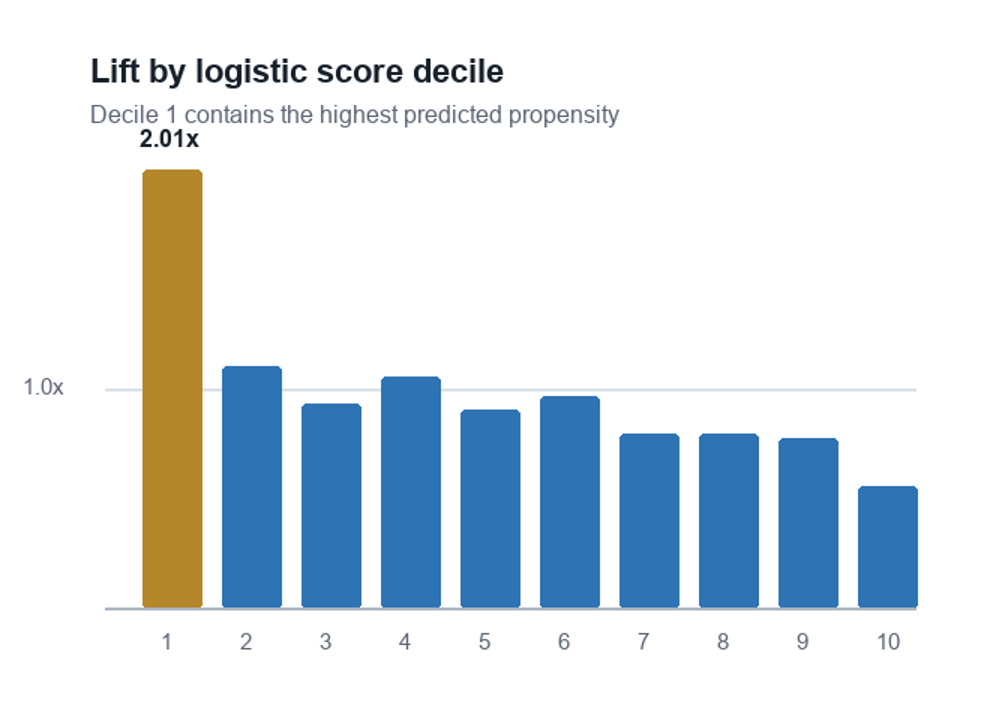

In [10]:
display(lift)
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(lift["score_decile"].astype(str), lift["lift_vs_average"],
       color=[COLORS[1]] + [COLORS[0]] * 9)
ax.axhline(1, color="#64748B", linestyle="--", linewidth=1)
ax.set_title("Hashed Logistic Regression Lift by Score Decile", loc="left", fontsize=15, weight="bold", pad=14)
ax.set_xlabel("Score decile (1 = highest predicted propensity)")
ax.set_ylabel("Lift vs. average")
ax.set_ylim(0, 2.25)
plt.tight_layout()
plt.show()

### 11. Inspect probability calibration

risk_band,sessions,predicted_rate,observed_rate
1,8153,0.007078,0.006255
2,8153,0.008847,0.008831
3,8153,0.009784,0.009076
4,8152,0.010667,0.009078
5,8153,0.011568,0.010548
6,8153,0.012368,0.010671
7,8152,0.013217,0.011899
8,8153,0.014272,0.010548
9,8153,0.016729,0.012511
10,8152,0.027472,0.022448


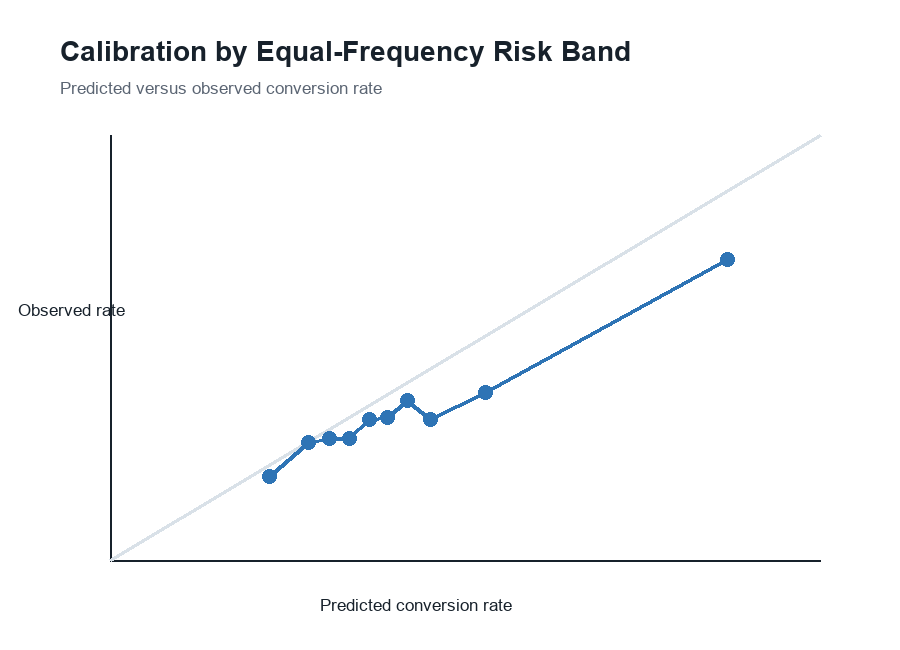

In [11]:
calibration = calibration_table(y_test, p_logistic)
display(calibration)
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(calibration["predicted_rate"]*100, calibration["observed_rate"]*100,
        marker="o", color=COLORS[0], linewidth=2, label="Model")
limit = max(calibration["predicted_rate"].max(), calibration["observed_rate"].max())*100*1.1
ax.plot([0, limit], [0, limit], linestyle="--", color="#64748B", label="Perfect calibration")
ax.set_title("Calibration by Equal-Frequency Risk Band", loc="left", fontsize=15, weight="bold", pad=14)
ax.set_xlabel("Predicted conversion rate (%)")
ax.set_ylabel("Observed conversion rate (%)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Takeaways

The model offers modest but operationally useful ranking signal. It should be used to stratify randomized experiments, not to infer causality or exclude customers. Discovery and product-detail interventions deserve priority because the largest losses occur before cart and checkout.

### Reproducibility checks

In [12]:
assert len(df) == 310_014
assert int(df["converted"].sum()) == 4_247
assert len(train) == 228_487 and int(y_train.sum()) == 3_335
assert len(test) == 81_527 and int(y_test.sum()) == 912
assert 1.9 < results.loc["Hashed logistic regression", "Top-10% lift"] < 2.1
print("All reproducibility checks passed.")

All reproducibility checks passed.


### Limitations

- The observation window is short and includes seasonal behavior.
- Session-start context cannot represent product intent that appears later in a visit.
- Funnel findings are descriptive; intervention impact must be established experimentally.
- Model calibration and feature drift should be monitored before production use.